In [16]:
import sys
sys.path.append('..')

In [ ]:
from src.l1_tools import *
import pandas as pd
import json

In [3]:
df = pd.read_csv("../data/processed/cloudy_sky_mean_profiles.csv")

analog_parallel = df["RCS_04"].values
analog_perpendicular = df["RCS_02"].values
photocounting_parallel = df["RCS_05"].values
photocounting_perpendicular = df["RCS_03"].values

altitude = df["Altitude_m"].values


print(np.shape(altitude))


(4000,)


In [4]:
Calibration_file_path = "../data/processed/calibration_constants.json"

with open(Calibration_file_path, "r") as f:
    calib_data = json.load(f)

# 3. Extract ALL 8 calibration constants
K_ph_par = calib_data["K_ph_par"]
delta_ph_par = calib_data["delta_ph_par"]

K_ph_per = calib_data["K_ph_per"]
delta_ph_per = calib_data["delta_ph_per"]

K_analog_per = calib_data["K_analog_per"]
delta_analog_per = calib_data["delta_analog_per"]

K_analog_par = calib_data["K_analog_par"]
delta_analog_par = calib_data["delta_analog_par"]

# 4. Extract BOTH masks (they will automatically be Python lists!)
mask_transition_perpendicular = calib_data["mask_transition_perpendicular"]
mask_transition_parallel = calib_data["mask_transition_parallel"]

print(" All calibration constants and masks loaded successfully!")


 All calibration constants and masks loaded successfully!


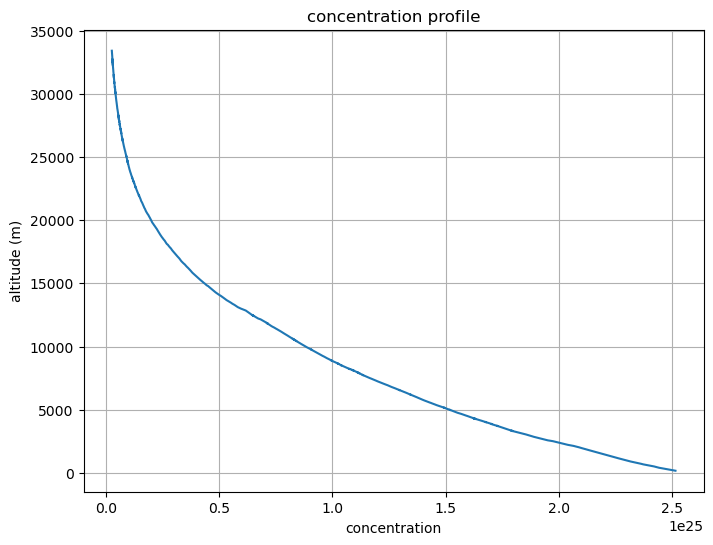

In [5]:
rs_file="../data/raw/rs_2a_GRUAN_TRP_M10_20250704_231547_v2.0.1.nc"

conc , alt_rs , temp = conc_calculation(rs_file)

plt.figure(figsize=(8,6))
plt.plot(conc, alt_rs)
plt.title("concentration profile")
plt.xlabel("concentration")
plt.ylabel("altitude (m)")
plt.grid()
plt.show()

In [6]:
depolarization_ratio_mol = 0.004
AMB_clear  , beta_ray , alpha_ray =  calculate_AMB_clear( conc ,alt_rs, altitude  )
AMB_clear_parallel = AMB_clear / (1 + depolarization_ratio_mol)
AMB_clear_perpendicular = (AMB_clear * depolarization_ratio_mol )/ (1 + depolarization_ratio_mol)


beta_ray_parallel = beta_ray / (1 + depolarization_ratio_mol)
beta_ray_perpendicular = (beta_ray * depolarization_ratio_mol )/ (1 + depolarization_ratio_mol)



In [7]:
AMB_clear =remove_nans_interpolation(AMB_clear, altitude)
AMB_clear_parallel =remove_nans_interpolation(AMB_clear_parallel, altitude)
AMB_clear_perpendicular =remove_nans_interpolation(AMB_clear_perpendicular, altitude)

beta_ray = remove_nans_interpolation(beta_ray, altitude)
beta_ray_parallel = remove_nans_interpolation(beta_ray_parallel, altitude)
beta_ray_perpendicular = remove_nans_interpolation(beta_ray_perpendicular, altitude)   

In [8]:
# filtering
analog_parallel=gaussian_filter(analog_parallel , altitude , max_sigma=5  )
analog_perpendicular=gaussian_filter(analog_perpendicular , altitude , max_sigma=5  )  

# filtering 
photocounting_parallel=gaussian_filter(photocounting_parallel , altitude , max_sigma=5  )
photocounting_perpendicular=gaussian_filter(photocounting_perpendicular , altitude , max_sigma=5  )



In [9]:
ATB_analog_parallel =K_analog_par * (analog_parallel- delta_analog_par)
ATB_analog_perpendicular = K_analog_per * (analog_perpendicular - delta_analog_per)
ATB_photocounting_parallel = K_ph_par * (photocounting_parallel - delta_ph_par)
ATB_photocounting_perpendicular = K_ph_per * (photocounting_perpendicular - delta_ph_per)

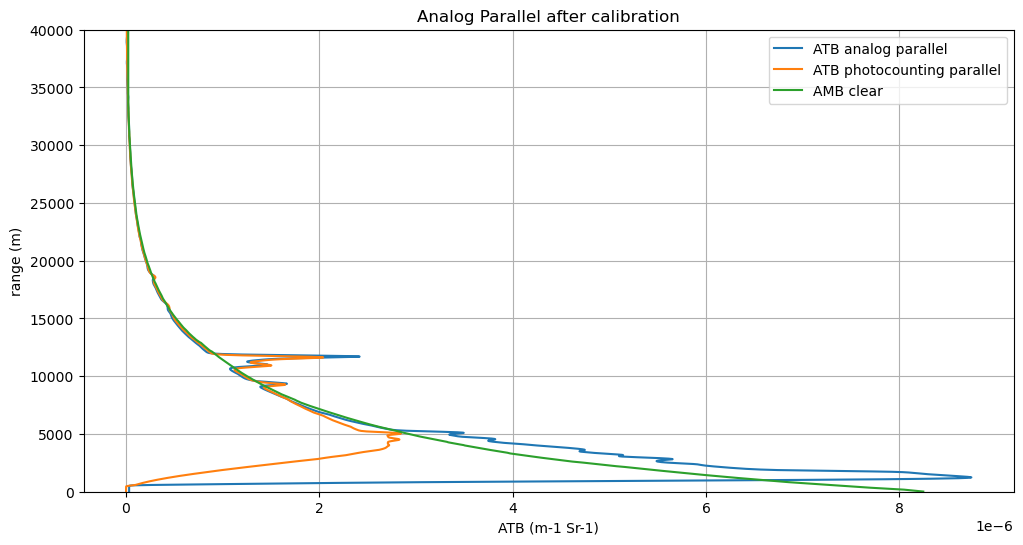

In [10]:
plt.figure(figsize=(12, 6))

plt.title("Analog Parallel after calibration")  
plt.plot(ATB_analog_parallel , altitude , label="ATB analog parallel")
plt.plot(ATB_photocounting_parallel , altitude , label="ATB photocounting parallel")
plt.plot(AMB_clear_parallel , altitude , label="AMB clear")
plt.ylim((0, 40000))
plt.grid(True)
plt.xlabel("ATB (m-1 Sr-1)")
plt.ylabel("range (m)")
plt.legend()

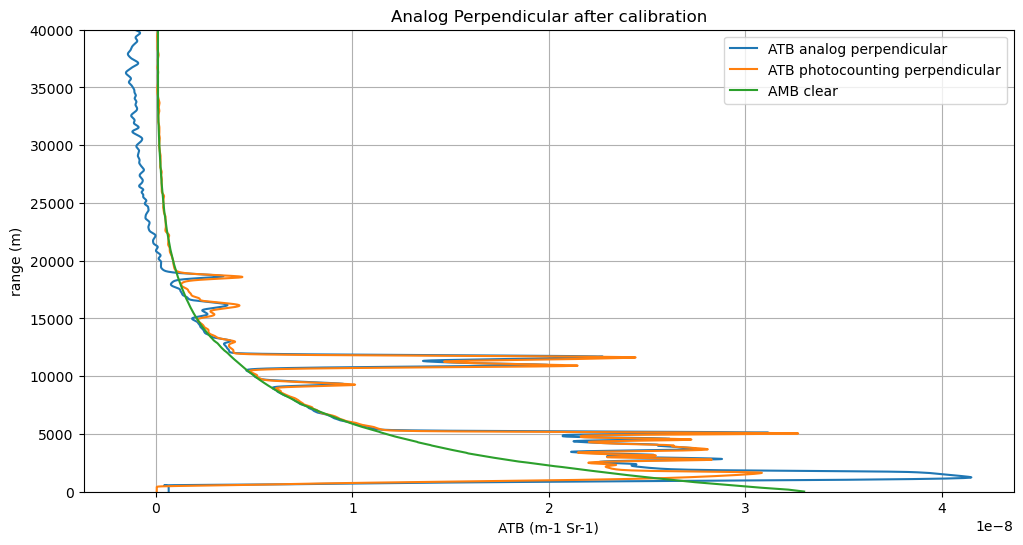

In [11]:
plt.figure(figsize=(12, 6))

plt.title("Analog Perpendicular after calibration")  
plt.plot(ATB_analog_perpendicular , altitude , label="ATB analog perpendicular")
plt.plot(ATB_photocounting_perpendicular , altitude , label="ATB photocounting perpendicular")
plt.plot(AMB_clear_perpendicular , altitude , label="AMB clear")
plt.ylim((0, 40000))
plt.grid(True)
plt.xlabel("ATB (m-1 Sr-1)")
plt.ylabel("range (m)")
plt.legend()

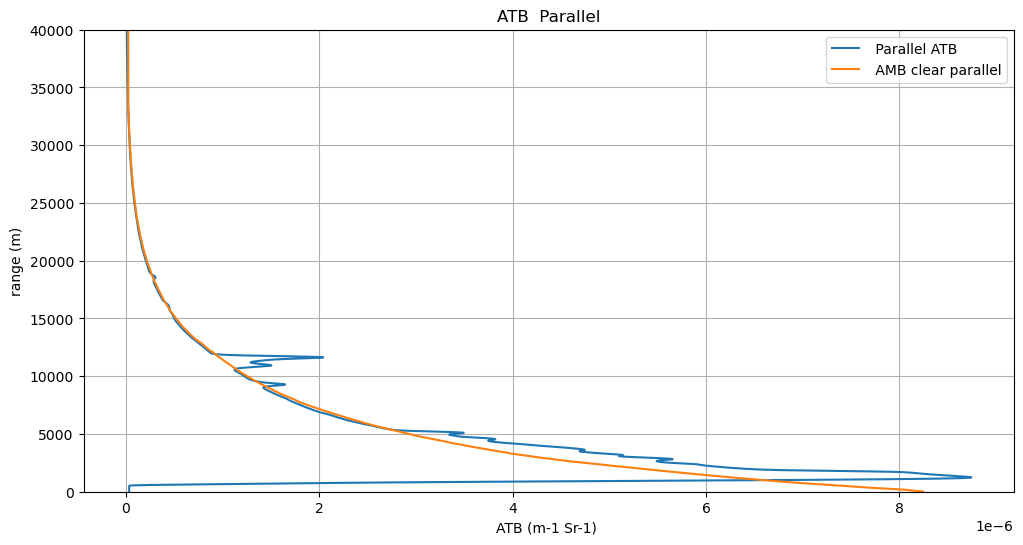

In [12]:
ATB_par= merged_signal_hanning(ATB_analog_parallel, ATB_photocounting_parallel, altitude, transition_start=mask_transition_parallel[0], transition_end=mask_transition_parallel[1])


plt.figure(figsize=(12, 6))
plt.title("ATB  Parallel")
plt.plot(ATB_par , altitude , label=' Parallel ATB')  
plt.plot(AMB_clear_parallel, altitude , label=' AMB clear parallel' )   
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)


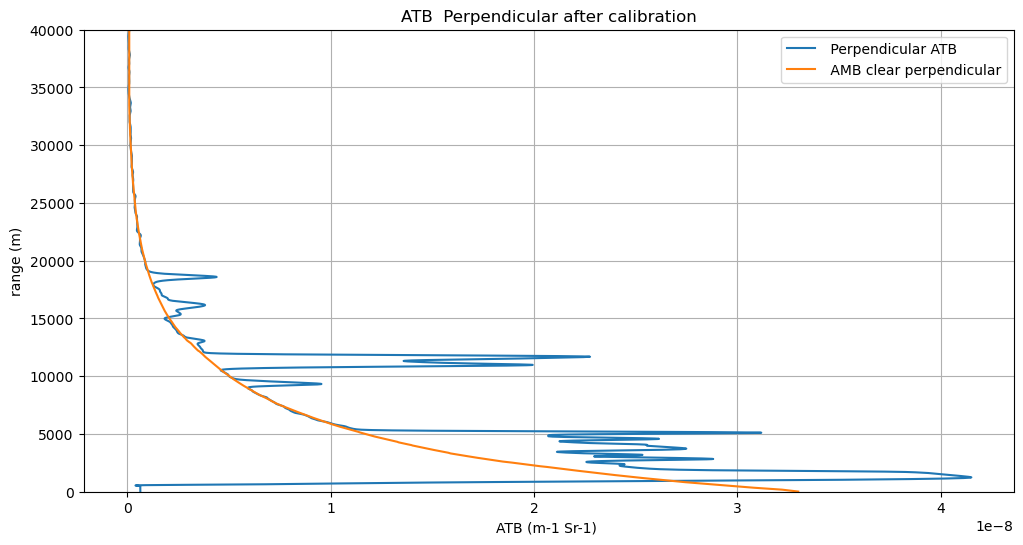

In [13]:
ATB_per = merged_signal_hanning(ATB_analog_perpendicular, ATB_photocounting_perpendicular, altitude, transition_start=mask_transition_perpendicular[0], transition_end=mask_transition_perpendicular[1])

plt.figure(figsize=(12, 6))
plt.title("ATB  Perpendicular after calibration")
plt.plot(ATB_per , altitude , label=' Perpendicular ATB')  
plt.plot(AMB_clear_perpendicular, altitude , label=' AMB clear perpendicular' )   
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)

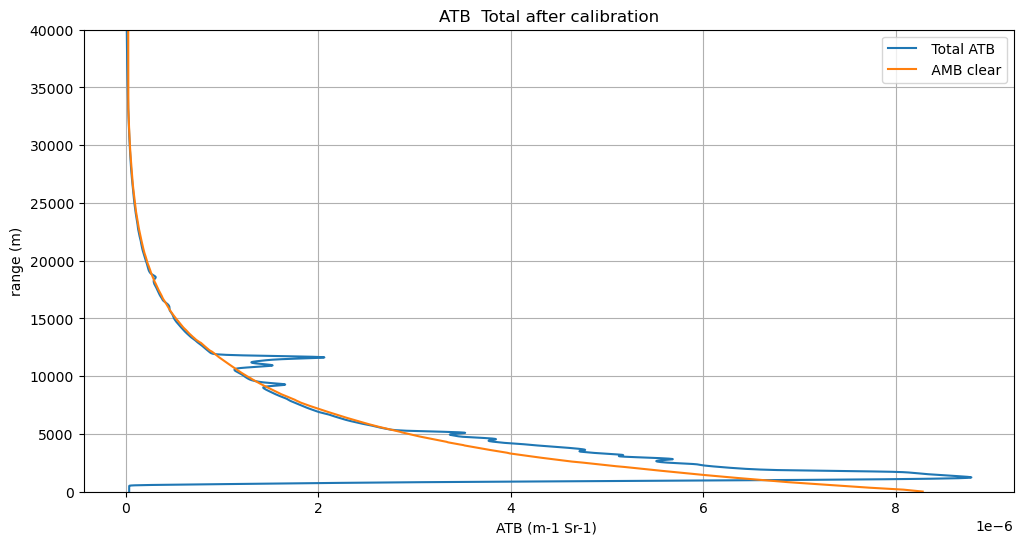

In [14]:
ATB_total = ATB_par + ATB_per

plt.figure(figsize=(12, 6))
plt.title("ATB  Total after calibration")
plt.plot(ATB_total , altitude , label=' Total ATB')  
plt.plot(AMB_clear, altitude , label=' AMB clear' )  
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)

In [15]:
df_atb = pd.DataFrame({
    "Altitude_m": altitude,
    "ATB_total": ATB_total,       
    "ATB_par": ATB_par,       
    "ATB_per": ATB_per   
})

# Save On csv file
df_atb.to_csv("../data/processed/L01_atb_profiles.csv", index=False)

print(" ATB profiles successfully saved to CSV!")

 ATB profiles successfully saved to CSV!
